In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import torch
import matplotlib.pyplot as plt
from src.data_processing.utils import set_seed
import pandas as pd
from torch.utils.data import DataLoader, Dataset
import joblib
from datetime import datetime
import yfinance as yf

from src.models.TimeGAN_torch.conditional_timegan_forecasting import CondTimeGANForecast
from src.models.TimeGAN_torch.metrics.visualization_metrics import visualization
from src.data_processing.utils import prepare_timegan_data_forecasting
from src.data_processing.signals import get_sp500_market_regime


%load_ext autoreload
%autoreload 2

In [2]:
# Need to set random seed for libraries, GPU, etc. for reproducibility 

set_seed(42)

Random seed set to: 42


## Set Network Parameters

seq_len is the length of the time series sequences. In this case seq_len=24 which represents 24 consecutive trading days
n_seq is the number of features, the CBOE VIX_history.csv dataset provided 4 features (CLOSE, LOW, HIGH, OPEN)

**going to incorportate monthly returns and "market regime" for now to use as conditional variables, will replace with markert-wide RV after testing the model**

In [3]:
# Newtork parameters
parameters = dict()

parameters['module'] = 'gru'
parameters['hidden_dim'] = 32
parameters['num_layers'] = 3
parameters['batch_size'] = 32
parameters['seq_len'] = 21
parameters['lr'] = 2e-4
parameters['device'] = torch.device("cuda" if torch.cuda.is_available() else "cpu")
parameters['epochs'] = 250
parameters['dataset_name'] = 'VIX'
parameters["cond_dim"] = 4
parameters["forecast_horizon"] = 21

In [4]:
data_path = './data/real_data/VIX_History.csv'
scaler_path = './model_checkpoints/scalers/scaler_VIX.pkl'

# Load the VIX history data and remove unwanted initial rows
all_data = pd.read_csv(data_path).iloc[505:].reset_index(drop=True)

# Correct the date format in the DATE column
all_data['DATE'] = [datetime.strptime(date, '%m/%d/%Y').strftime('%Y-%m-%d') for date in all_data['DATE']]

# Fetch S&P 500 data for the corresponding date range
sp500_data = get_sp500_market_regime(start_date=all_data['DATE'].iloc[0], end_date=all_data['DATE'].iloc[-1])

# Merge the datasets on the DATE column to align them
merged_data = pd.merge(all_data, sp500_data, left_on='DATE', right_on='Date', how='inner')

# Remove rows with any NaN values to ensure data quality
cleaned_data = merged_data.dropna().reset_index(drop=True)

# Reset start of data since there monthly returns were calculated
cleaned_data = cleaned_data.iloc[1:]

# Remove the DATE column
cleaned_data.drop(['DATE'], axis=1, inplace=True)
cleaned_data.drop(['Date'], axis=1, inplace=True)

parameters['n_seq'] = cleaned_data.shape[1] - 2

[*********************100%***********************]  1 of 1 completed


In [5]:
# Apply function to dataset
train_data, val_data, test_data = prepare_timegan_data_forecasting(cleaned_data, forecast_horizon=parameters["forecast_horizon"])

(8274, 21, 4)
(8274, 21, 4)
(8274, 21, 4)


## Run TimeGAN for synthetic time-series data generation

In [6]:
# Run TimeGAN
model = CondTimeGANForecast(parameters)

Model initialized with ID: VIX_20250301_000539_84af5f44_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4_forecast_horizon21


In [7]:
model.train(train_data,
            val_data,
            ae_iters=parameters['epochs'], 
            sup_iters=parameters['epochs'], 
            joint_iters=parameters['epochs'], 
            patience = 15)

[Training] Phase 1: Autoencoder
[Autoencoder] Epoch 1/250, Train Loss: 1.8231, Val Loss: 1.3315
[Autoencoder] Epoch 11/250, Train Loss: 0.2326, Val Loss: 0.2496
[Autoencoder] Epoch 21/250, Train Loss: 0.1736, Val Loss: 0.1759
[Autoencoder] Epoch 31/250, Train Loss: 0.1530, Val Loss: 0.1628
[Autoencoder] Epoch 41/250, Train Loss: 0.1429, Val Loss: 0.1493
[Autoencoder] Epoch 51/250, Train Loss: 0.1382, Val Loss: 0.1514
[Autoencoder] Epoch 61/250, Train Loss: 0.1349, Val Loss: 0.1475
[Autoencoder] Epoch 71/250, Train Loss: 0.1319, Val Loss: 0.1446
[Autoencoder] Epoch 81/250, Train Loss: 0.1291, Val Loss: 0.1438
[Autoencoder] Epoch 91/250, Train Loss: 0.1273, Val Loss: 0.1435
[Autoencoder] Epoch 101/250, Train Loss: 0.1251, Val Loss: 0.1380
[Autoencoder] Epoch 111/250, Train Loss: 0.1240, Val Loss: 0.1417
[Autoencoder] Early stopping at epoch 115 with best Val Loss: 0.1380
[Autoencoder] Restored best model from early stopping.
[Training] Phase 2: Supervisor
[Supervisor] Epoch 1/250, Train 

6.360857083247258

## Evaluate the generated data

In [8]:
import torch
import torch.nn.functional as F
import numpy as np

def evaluate_generated_sequences(model, test_loader):
    """
    Evaluate the Conditional TimeGAN model in a forecasting context.
    The idea: for each batch, we encode the real input X, then decode
    to generate a forecast, and compare it with the actual future Y.

    Args:
        model: A trained CondTimeGANForecast model (with encoder, decoder, etc.).
        test_loader: DataLoader providing (X, Y, cond) batches, where:
            X has shape [batch_size, seq_len, n_seq]
            Y has shape [batch_size, forecast_horizon, n_seq]
            cond has shape [batch_size, cond_dim]

    Returns:
        avg_mse (float): The MSE over the entire test set.
        all_forecasts (np.ndarray): Concatenated predictions (N, forecast_horizon, n_seq).
        all_actuals (np.ndarray): Concatenated ground-truth sequences (N, forecast_horizon, n_seq).
    """

    model.encoder.eval()
    model.decoder.eval()
    model.generator.eval()   # Not strictly needed if you don't use it here
    model.supervisor.eval()  # Not strictly needed if you don't use it here

    device = model.device

    total_mse = 0.0
    total_samples = 0
    forecast_list = []
    actual_list = []

    with torch.no_grad():
        for X_mb, Y_mb, cond_mb in test_loader:
            # Move to device
            X_mb = X_mb.to(device)
            Y_mb = Y_mb.to(device)
            cond_mb = cond_mb.to(device)

            # 1) Encode real past sequence
            #    shape: [batch_size, seq_len, hidden_dim]
            H = model.encoder(X_mb, cond_mb)

            # 2) Decode hidden state to obtain multi-step forecast
            #    shape: [batch_size, forecast_horizon, n_seq]
            Y_hat = model.decoder(H, cond_mb)

            # 3) Compute MSE with the actual future
            #    shape check: Y_hat vs. Y_mb
            mse = F.mse_loss(Y_hat, Y_mb, reduction='mean')
            batch_size = X_mb.size(0)

            total_mse += mse.item() * batch_size
            total_samples += batch_size

            # 4) Save for later analysis/plotting
            forecast_list.append(Y_hat.cpu().numpy())
            actual_list.append(Y_mb.cpu().numpy())

    # Aggregate results
    avg_mse = total_mse / max(total_samples, 1)
    all_forecasts = np.concatenate(forecast_list, axis=0)
    all_actuals = np.concatenate(actual_list, axis=0)

    return avg_mse, all_forecasts, all_actuals

[Model Loaded] Successfully loaded model from ./model_checkpoints/VIX/VIX_20250301_000539_84af5f44_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4_forecast_horizon21 (ID: VIX_20250301_000539_84af5f44_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4_forecast_horizon21)


Test MSE: 0.007788255447720199


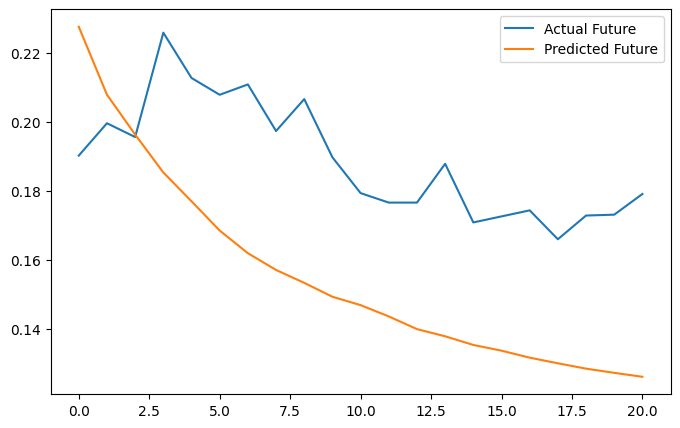

In [9]:
# Load the trained model
model.load_model('./model_checkpoints/VIX/VIX_20250301_000539_84af5f44_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4_forecast_horizon21')

test_loader = DataLoader(train_data, batch_size=32, shuffle=False)

# 3) Evaluate
mse_score, forecasts, actuals = evaluate_generated_sequences(model, test_loader)
print("Test MSE:", mse_score)

# 4) Optionally visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# Plot the first sample’s first feature dimension as an example
plt.plot(actuals[0,:,0], label="Actual Future")
plt.plot(forecasts[0,:,0], label="Predicted Future")
plt.legend()
plt.show()

## Inverse-transform generated sequences

The generated sequences are normalized using MinMax(), need to inverse transform the data

In [ ]:
# Load the scaler
scaler_path = f'./model_checkpoints/scalers/scaler_{dataset_name}.pkl'
scaler = joblib.load(scaler_path)

# Reshape synthetic_data from (n_samples, n_timesteps, n_features) to (n_samples * n_timesteps, n_features)
n_samples, n_timesteps, n_features = synthetic_data.shape
synthetic_data_reshaped = synthetic_data.reshape(-1, n_features)

# Inverse transform
synthetic_data_inv = scaler.inverse_transform(synthetic_data_reshaped)

# Reshape back to (n_samples, n_timesteps, n_features)
# Each of the samples would represent a single block of time (e.g. synthetic_data_inv[i])
synthetic_data_inv = synthetic_data_inv.reshape(n_samples, n_timesteps, n_features)

# Example of a single block of 24 days
synth_df = pd.DataFrame(synthetic_data_inv[0], columns=all_data.columns)

synth_df.head()

In [ ]:
save_synth_data(synthetic_data_inv, 
                save_dir='./data/synthetic_data',
                dataset_name=parameters['dataset_name'],
                col_names=all_data.columns.tolist())